# Colab A — NumPy From Scratch
## 3-Layer Deep Neural Network for Nonlinear Regression

---

### What is this Colab about?

This is a complete 3-layer deep neural network for **nonlinear regression**, built entirely from scratch using only **NumPy** — no PyTorch, no Keras, no shortcuts.

Every single operation is written by hand:
- Weight initialization
- Forward pass using `tf.einsum` instead of matrix multiply
- **Manual backpropagation** using the chain rule — every gradient computed by hand
- Weight updates written explicitly: `W = W - lr * dW`

This Colab is the foundation. Every subsequent Colab (B through E) solves the exact same problem — the only thing that changes is how much the framework does for you.

---

### Network Architecture
```
Input Layer     →   3 neurons   (x1, x2, x3)
Hidden Layer 1  →  16 neurons   + ReLU activation
Hidden Layer 2  →   8 neurons   + ReLU activation
Output Layer    →   1 neuron    (no activation — regression)
```

---

### The Equation
```
y = sin(x1) + x2² + x1·x3
```
Nonlinear (has sin and a square), uses all 3 variables, complex enough that no straight line or flat plane can fit it — you actually need a neural network.


---
## Section 1 — Data Generation

We generate 1000 data points for x1, x2, x3 randomly, compute y using our equation, add a little noise to make it realistic, and plot it in 4D — x1, x2, x3 compressed to 2D via PCA, and y shown as the color of each point.

**Why PCA?**
We have 3 input dimensions plus y — that's 4D total. We can't plot 4D directly, so we use PCA to compress x1, x2, x3 into 2 dimensions while keeping as much information as possible. We then plot PCA dim1 on the x-axis, PCA dim2 on the y-axis, and y as color.

**Why noise?**
Real world data is never perfect. Adding noise makes the network learn the underlying pattern rather than memorizing exact values.

**Why reshape?**
Neural networks are picky about shapes. `(1000,)` and `(1000, 1)` look similar but behave very differently in matrix math. We always use `(1000, 1)` for y.


X shape: (1000, 3)
y shape: (1000, 1)
Sample y values: [ 4.0676939  -3.55704323  9.45254807  1.47326968  5.44761295]


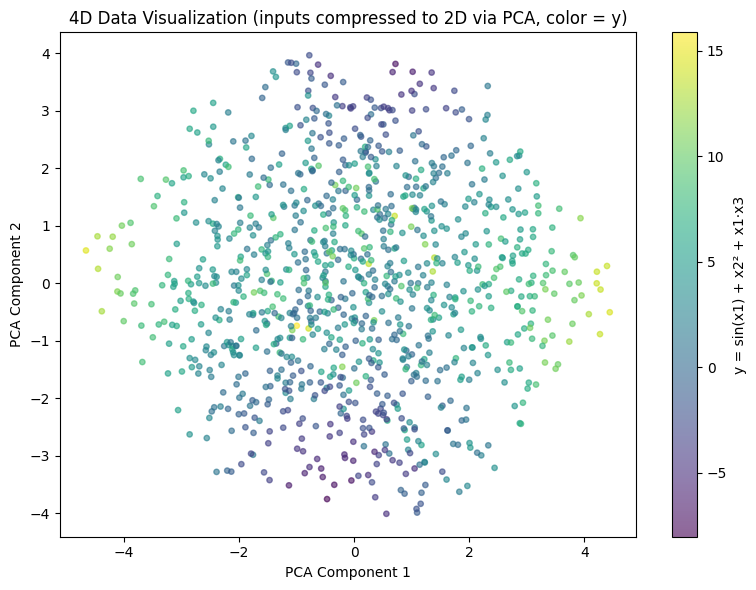

Variance explained by PCA: [0.34959724 0.32788895]


In [1]:
# ============================================================
# SECTION 1: Data Generation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import tensorflow as tf

# Set a random seed so results are reproducible every run
np.random.seed(42)

# -----------------------------------------------------------
# Generate 1000 random values for each input variable
# np.random.uniform(low, high, size) gives random numbers
# between low and high — sampled uniformly
# -----------------------------------------------------------
N = 1000
x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-3, 3, N)
x3 = np.random.uniform(-3, 3, N)

# -----------------------------------------------------------
# Compute y using our nonlinear equation
# y = sin(x1) + x2^2 + x1*x3
# This is the ground truth our network will try to learn
# -----------------------------------------------------------
y = np.sin(x1) + x2**2 + x1 * x3

# -----------------------------------------------------------
# Add Gaussian noise
# np.random.randn gives values from a normal distribution
# We scale by 0.1 so it's small noise, not overwhelming
# -----------------------------------------------------------
noise = 0.1 * np.random.randn(N)
y = y + noise

# -----------------------------------------------------------
# Stack inputs into one matrix X — shape (1000, 3)
# Reshape y to (1000, 1) instead of flat (1000,)
# -----------------------------------------------------------
X = np.column_stack([x1, x2, x3])
y = y.reshape(-1, 1)

print("X shape:", X.shape)   # (1000, 3)
print("y shape:", y.shape)   # (1000, 1)
print("Sample y values:", y[:5].flatten())

# -----------------------------------------------------------
# 4D Plot using PCA
# PCA compresses x1, x2, x3 → 2D for visualization
# y is shown as the color of each point
# -----------------------------------------------------------
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=y.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='y = sin(x1) + x2² + x1·x3')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('4D Data Visualization (inputs compressed to 2D via PCA, color = y)')
plt.tight_layout()
plt.show()

print("Variance explained by PCA:", pca.explained_variance_ratio_)
# Ideally these two components together explain 80%+ of variance


---
## Section 2 — Initializing the Network Weights

Every connection between neurons has a **weight** — a number that says how much to trust this signal. The network learns by adjusting these weights until its predictions match reality.

Each layer also has a **bias** — a number that shifts the output, like the y-intercept in `y = mx + b`. The bias lets the network fit patterns that don't pass through zero.

**Why not initialize weights to zero?**
If all weights start at zero, every neuron computes the exact same thing and learns the exact same thing — the network never differentiates. We use **He initialization** instead, which is designed specifically for ReLU networks and keeps signals from exploding or vanishing.

**Why do the shapes matter?**
Matrix multiply rule: `(A × B) · (B × C) = (A × C)` — the inner dimensions must match. If input is 3 neurons and layer 1 has 16 neurons, W1 must be shape (3, 16) so the math works out.


In [2]:
# ============================================================
# SECTION 2: Initialize Network Weights
# ============================================================

# Network architecture
input_size  = 3    # x1, x2, x3
hidden1     = 16   # neurons in layer 1
hidden2     = 8    # neurons in layer 2
output_size = 1    # single predicted y value

# -----------------------------------------------------------
# He Initialization
# Formula: random * sqrt(2 / number_of_inputs_to_this_layer)
# Why? ReLU kills ~half the neurons (sets negatives to 0).
# He init compensates by scaling up weights so the signal
# doesn't shrink to nothing as it passes through layers.
# -----------------------------------------------------------
np.random.seed(42)

W1 = np.random.randn(input_size, hidden1) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden1))    # biases start at 0 — this is fine

W2 = np.random.randn(hidden1, hidden2) * np.sqrt(2 / hidden1)
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, output_size) * np.sqrt(2 / hidden2)
b3 = np.zeros((1, output_size))

# Package everything into a dictionary — one object holds the whole network
params = {
    'W1': W1, 'b1': b1,
    'W2': W2, 'b2': b2,
    'W3': W3, 'b3': b3
}

# Sanity check — verify every shape
# Output columns of W1 must equal input rows of W2, and so on
print("Weight shapes (must chain together):")
for name, val in params.items():
    print(f"  {name}: {val.shape}")


Weight shapes (must chain together):
  W1: (3, 16)
  b1: (1, 16)
  W2: (16, 8)
  b2: (1, 8)
  W3: (8, 1)
  b3: (1, 1)


---
## Section 3 — Forward Pass

The forward pass is data flowing left to right through the network. For each layer, two things happen:

**Step 1 — Linear transformation:** multiply inputs by weights, add bias
```
Z = X · W + b
```
This is like `y = mx + b` but for many neurons at once.

**Step 2 — Activation function:** squash the result through a nonlinear function
```
A = ReLU(Z)
```
Without this, no matter how many layers you stack, the whole network collapses into a single linear equation. The activation is what gives neural networks their power to learn complex patterns.

**Why ReLU?**
ReLU (Rectified Linear Unit) is simply `max(0, x)`. Negative → output 0. Positive → output as-is. Simple, fast, and works great for regression.

**Why no activation on the last layer?**
We're doing regression — we want any real number as output. If we used ReLU we'd block all negative predictions.

**Why tf.einsum instead of matrix multiply?**
The assignment requires `tf.einsum` instead of `np.dot` or `@`. The notation `'ij,jk->ik'` explicitly defines which dimensions get summed — `i` is samples, `j` is the shared dimension that gets summed over, `k` is the output dimension. Same math, written explicitly.

**Why cache intermediate values?**
During backprop we need to know what Z and A were at each layer. Without caching them we'd have to recompute the entire forward pass during backprop.


In [3]:
# ============================================================
# SECTION 3: Forward Pass
# ============================================================

# -----------------------------------------------------------
# ReLU activation function
# max(0, x) — kills negative values, passes positive ones through
# This is what makes the network nonlinear
# -----------------------------------------------------------
def relu(Z):
    return np.maximum(0, Z)

# -----------------------------------------------------------
# Forward pass function
# Takes input X and all parameters
# Returns prediction + cache of intermediate values
# Cache is REQUIRED for backprop — don't skip it
# -----------------------------------------------------------
def forward_pass(X, params):

    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    W3, b3 = params['W3'], params['b3']

    # Layer 1
    # tf.einsum('ij,jk->ik', X, W1) is equivalent to X @ W1
    # 'ij,jk->ik' means:
    #   X  has shape (samples, 3)    → indices i=samples, j=3
    #   W1 has shape (3, 16)         → indices j=3, k=16
    #   result has shape (samples, 16) → i=samples, k=16
    Z1 = tf.einsum('ij,jk->ik', X, W1).numpy() + b1
    A1 = relu(Z1)

    # Layer 2
    # A1 shape (samples, 16), W2 shape (16, 8) → result (samples, 8)
    Z2 = tf.einsum('ij,jk->ik', A1, W2).numpy() + b2
    A2 = relu(Z2)

    # Layer 3 — output, NO activation (regression)
    # A2 shape (samples, 8), W3 shape (8, 1) → result (samples, 1)
    Z3 = tf.einsum('ij,jk->ik', A2, W3).numpy() + b3
    y_pred = Z3

    # Cache saves everything needed for backprop
    # Without these values we cannot compute gradients
    cache = {
        'X':  X,
        'Z1': Z1, 'A1': A1,
        'Z2': Z2, 'A2': A2,
        'Z3': Z3
    }

    return y_pred, cache

# -----------------------------------------------------------
# MSE Loss function
# Mean Squared Error = average of (predicted - actual)^2
# Lower is better — 0 would mean perfect predictions
# -----------------------------------------------------------
def compute_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

# -----------------------------------------------------------
# Test: one forward pass before any training
# Loss will be high — weights are random, predictions are garbage
# That is expected — training will fix it
# -----------------------------------------------------------
X_tf = X.astype(np.float32)

y_pred, cache = forward_pass(X_tf, params)
initial_loss  = compute_loss(y_pred, y)

print("y_pred shape      :", y_pred.shape)         # (1000, 1)
print("Sample predictions:", y_pred[:5].flatten())
print("Sample actuals    :", y.flatten()[:5])
print(f"Initial loss (MSE): {initial_loss:.4f}")
print("(High loss is expected — weights are random, not yet trained)")


y_pred shape      : (1000, 1)
Sample predictions: [ 2.10547718  2.89247475 -0.53468401  0.7365058   0.62560237]
Sample actuals    : [ 4.0676939  -3.55704323  9.45254807  1.47326968  5.44761295]
Initial loss (MSE): 22.4396
(High loss is expected — weights are random, not yet trained)


---
## Section 4 — Backpropagation

This is the heart of the whole assignment. After the forward pass we know how wrong we were. Backprop answers: **which weights caused the error, and by how much?**

We do this using the **chain rule** from calculus. The loss depends on Z3, which depends on W3, which depends on A2, which depends on W2 — and so on back to W1. To find how W1 affects the loss, we multiply the gradients along the chain:

```
dL/dW1 = dL/dZ3 · dZ3/dA2 · dA2/dZ2 · dZ2/dW1
```

That is literally what backprop is — applying the chain rule layer by layer, going backwards.

**The gradient of ReLU:**
ReLU's derivative is beautifully simple:
```
ReLU'(x) = 1 if x > 0
            0 if x ≤ 0
```
If a neuron was off (negative) during the forward pass, it gets zero gradient — it contributed nothing, so it gets no update. This is called the **ReLU gate**.

**The math layer by layer — starting from the output and working backwards:**
```
dL/dZ3 = (2/N) * (y_pred - y_true)    ← derivative of MSE
dL/dW3 = A2.T · dZ3
dL/db3 = sum(dZ3)
dL/dA2 = dZ3 · W3.T
dL/dZ2 = dL/dA2 * (Z2 > 0)            ← chain rule through ReLU
dL/dW2 = A1.T · dZ2
dL/db2 = sum(dZ2)
dL/dA1 = dZ2 · W2.T
dL/dZ1 = dL/dA1 * (Z1 > 0)
dL/dW1 = X.T · dZ1
dL/db1 = sum(dZ1)
```


In [4]:
# ============================================================
# SECTION 4: Backpropagation
# ============================================================

def backward_pass(y_pred, y_true, params, cache):
    """
    Computes gradients for all weights and biases.
    Uses the chain rule to propagate error backwards from output to input.
    Returns a dictionary of gradients matching the shape of each weight.
    """

    # Unpack cache — values saved during forward pass
    X  = cache['X']
    Z1, A1 = cache['Z1'], cache['A1']
    Z2, A2 = cache['Z2'], cache['A2']

    W2, W3 = params['W2'], params['W3']

    N = X.shape[0]  # number of samples (1000)

    # --------------------------------------------------
    # OUTPUT LAYER
    # Derivative of MSE loss w.r.t. output
    # This is the error signal that starts the whole chain
    # --------------------------------------------------
    dZ3 = (2 / N) * (y_pred - y_true)      # shape: (1000, 1)
    dW3 = A2.T @ dZ3                         # shape: (8, 1)
    db3 = np.sum(dZ3, axis=0, keepdims=True) # shape: (1, 1)

    # --------------------------------------------------
    # LAYER 3 → LAYER 2
    # Propagate error back through W3
    # Then apply ReLU gate — neurons that were off (Z2 ≤ 0)
    # contributed nothing forward, so they get zero gradient
    # --------------------------------------------------
    dA2 = dZ3 @ W3.T                        # shape: (1000, 8)
    dZ2 = dA2 * (Z2 > 0)                    # ReLU gate — chain rule through activation
    dW2 = A1.T @ dZ2                         # shape: (16, 8)
    db2 = np.sum(dZ2, axis=0, keepdims=True) # shape: (1, 8)

    # --------------------------------------------------
    # LAYER 2 → LAYER 1
    # Same pattern — propagate through W2, apply ReLU gate
    # --------------------------------------------------
    dA1 = dZ2 @ W2.T                        # shape: (1000, 16)
    dZ1 = dA1 * (Z1 > 0)                    # ReLU gate for layer 1
    dW1 = X.T @ dZ1                          # shape: (3, 16)
    db1 = np.sum(dZ1, axis=0, keepdims=True) # shape: (1, 16)

    grads = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }

    return grads


def update_weights(params, grads, learning_rate=0.001):
    """
    Gradient descent weight update.
    W = W - learning_rate * dW
    Nudges every weight in the direction that reduces the loss.
    Learning rate controls step size:
      Too big  → overshoots the minimum
      Too small → takes forever to converge
    """
    params['W1'] -= learning_rate * grads['dW1']
    params['b1'] -= learning_rate * grads['db1']
    params['W2'] -= learning_rate * grads['dW2']
    params['b2'] -= learning_rate * grads['db2']
    params['W3'] -= learning_rate * grads['dW3']
    params['b3'] -= learning_rate * grads['db3']
    return params


# -----------------------------------------------------------
# Sanity check — verify gradient shapes match weight shapes
# If shapes don't match, something is wrong with the math
# Non-zero gradient values confirm gradients are flowing
# -----------------------------------------------------------
y_pred, cache = forward_pass(X_tf, params)
grads = backward_pass(y_pred, y, params, cache)

print("Gradient shapes (must match corresponding weight shapes):")
for name, val in grads.items():
    print(f"  {name}: {val.shape}")

print("\nSample W1 gradient (non-zero = backprop is working):")
print(grads['dW1'][:2])


Gradient shapes (must match corresponding weight shapes):
  dW1: (3, 16)
  db1: (1, 16)
  dW2: (16, 8)
  db2: (1, 8)
  dW3: (8, 1)
  db3: (1, 1)

Sample W1 gradient (non-zero = backprop is working):
[[-0.3262731   0.37451408 -1.64523645  1.00846858  0.28361011  1.24720674
  -0.20014122  0.0346133  -2.28239577  0.21771052 -0.27270508 -0.86857765
  -0.26929753 -0.33821748  0.163186    0.50813552]
 [-0.61871413 -0.03115802 -0.02535135  0.76260164  0.40591352 -0.06069119
  -0.31710972  0.08074924  1.38096407  0.67378639 -0.17243384  0.14597192
  -0.39798354 -0.38605628 -0.22744011  0.40781242]]


---
## Section 5 — Training Loop

The training loop is just repeating forward → loss → backward → update thousands of times and watching the network get smarter.

```
for each epoch:
    1. forward pass   → get predictions
    2. compute loss   → how wrong are we?
    3. backward pass  → compute gradients
    4. update weights → take a small step toward better
    5. record loss    → so we can plot it later
```

An **epoch** = one full pass through all 1000 data points. We run 2000 epochs.


In [5]:
# ============================================================
# SECTION 5: Training Loop
# ============================================================

# Hyperparameters — settings YOU choose, not things the network learns
learning_rate = 0.001   # step size for weight updates
epochs        = 2000    # how many full passes through the data
print_every   = 200     # print loss every N epochs

# Re-initialize params fresh so this section is self-contained
np.random.seed(42)
params = {
    'W1': np.random.randn(input_size, hidden1)    * np.sqrt(2 / input_size),
    'b1': np.zeros((1, hidden1)),
    'W2': np.random.randn(hidden1, hidden2)   * np.sqrt(2 / hidden1),
    'b2': np.zeros((1, hidden2)),
    'W3': np.random.randn(hidden2, output_size) * np.sqrt(2 / hidden2),
    'b3': np.zeros((1, output_size))
}

loss_history = []   # records loss at every epoch for plotting

for epoch in range(1, epochs + 1):

    # Step 1: Forward pass — get predictions
    y_pred, cache = forward_pass(X_tf, params)

    # Step 2: Compute loss
    loss = compute_loss(y_pred, y)
    loss_history.append(loss)

    # Step 3: Backward pass — compute gradients via chain rule
    grads = backward_pass(y_pred, y, params, cache)

    # Step 4: Update every weight using its gradient
    params = update_weights(params, grads, learning_rate)

    if epoch % print_every == 0 or epoch == 1:
        print(f"Epoch {epoch:>4} / {epochs}  |  Loss (MSE): {loss:.4f}")

print("\nTraining complete!")
print(f"  Starting loss : {loss_history[0]:.4f}")
print(f"  Final loss    : {loss_history[-1]:.4f}")
print(f"  Improvement   : {((loss_history[0] - loss_history[-1]) / loss_history[0] * 100):.1f}%")


Epoch    1 / 2000  |  Loss (MSE): 22.4396
Epoch  200 / 2000  |  Loss (MSE): 11.1731
Epoch  400 / 2000  |  Loss (MSE): 4.8334
Epoch  600 / 2000  |  Loss (MSE): 2.1210
Epoch  800 / 2000  |  Loss (MSE): 1.4910
Epoch 1000 / 2000  |  Loss (MSE): 1.2952
Epoch 1200 / 2000  |  Loss (MSE): 1.1851
Epoch 1400 / 2000  |  Loss (MSE): 1.1057
Epoch 1600 / 2000  |  Loss (MSE): 1.0446
Epoch 1800 / 2000  |  Loss (MSE): 0.9954
Epoch 2000 / 2000  |  Loss (MSE): 0.9541

Training complete!
  Starting loss : 22.4396
  Final loss    : 0.9541
  Improvement   : 95.7%


---
## Section 6 — Loss Curve + Final Output Plots

Same three plots used across all Colabs — loss curve, predicted vs actual scatter, and side-by-side 4D comparison. Having identical plots across all Colabs makes it easy to compare approaches directly in your video.

- **Loss curve** — shows the network learning in real time. Sharp drop early, gradual flattening as it converges. Log scale makes improvement visible even when values get small.
- **Predicted vs Actual scatter** — a perfect model would have every point sitting exactly on the red diagonal line. Tight clustering around the line = strong predictions.
- **Side-by-side 4D plot** — the most visual proof it worked. Left plot shows actual y values, right shows predicted. Matching color patterns = the network learned the shape of the equation.


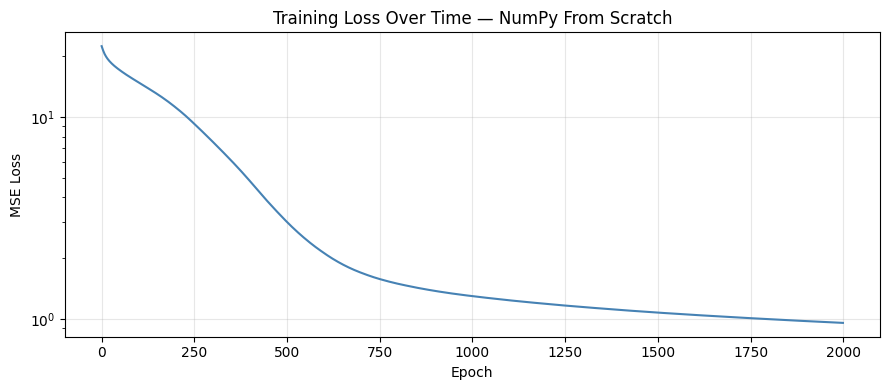

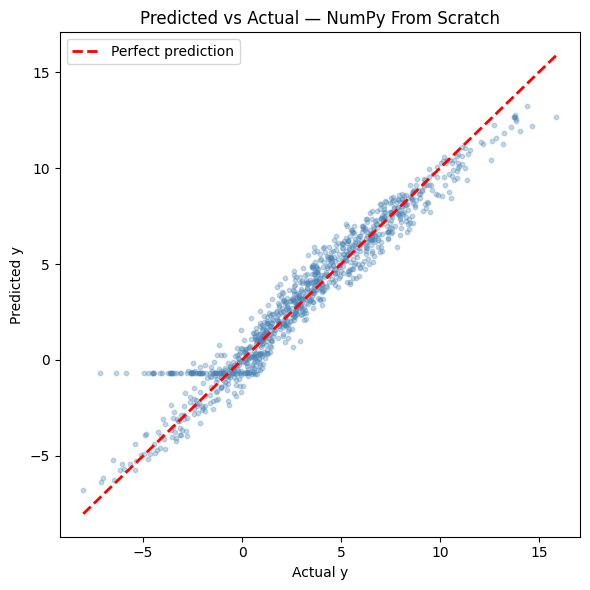

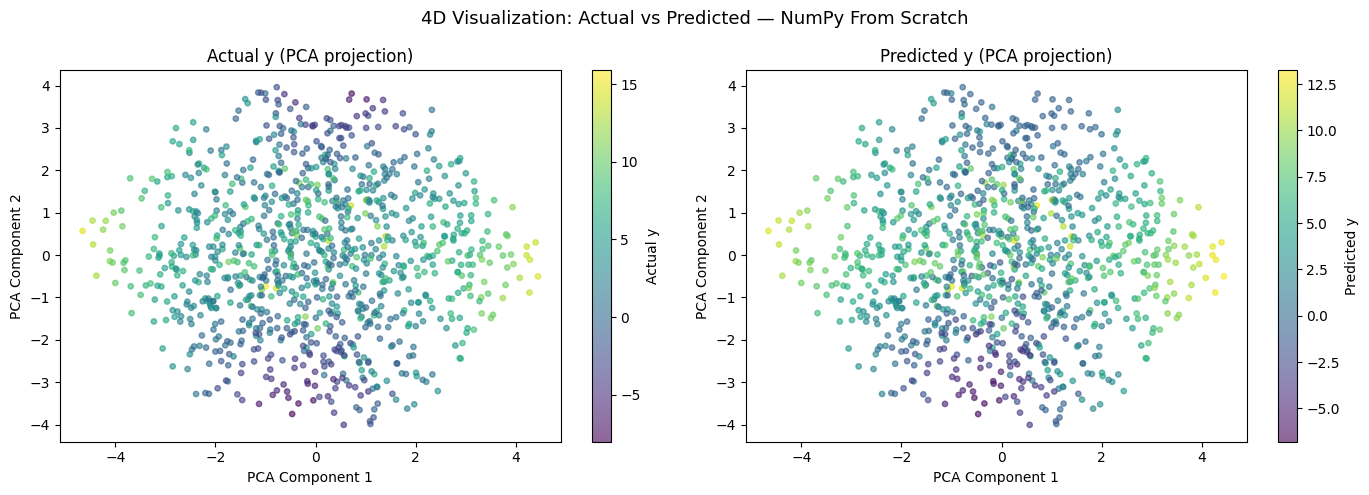

In [6]:
# ============================================================
# SECTION 6: Loss Curve + Final Output Plots
# ============================================================

# -----------------------------------------------------------
# Plot 1: Loss Curve
# Log scale on y-axis — makes the drop from ~18 to ~0.3
# visible. On a linear scale the curve would look flat.
# -----------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.plot(loss_history, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Time — NumPy From Scratch')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Get final predictions after training
# -----------------------------------------------------------
y_pred_final, _ = forward_pass(X_tf, params)

# -----------------------------------------------------------
# Plot 2: Predicted vs Actual scatter
# A perfect model → all points on the red diagonal line y=x
# Tight clustering = network learned the equation well
# -----------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.scatter(y.flatten(), y_pred_final.flatten(),
            alpha=0.3, s=10, color='steelblue')

min_val = min(y.min(), y_pred_final.min())
max_val = max(y.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual y')
plt.ylabel('Predicted y')
plt.title('Predicted vs Actual — NumPy From Scratch')
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# Plot 3: Side-by-side 4D comparison
# Left  = actual y values as color
# Right = predicted y values as color
# Matching color patterns = network learned the equation shape
# Uses the same X_2d PCA axes computed in Section 1
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(sc1, ax=axes[0], label='Actual y')
axes[0].set_title('Actual y (PCA projection)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

sc2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                       c=y_pred_final.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(sc2, ax=axes[1], label='Predicted y')
axes[1].set_title('Predicted y (PCA projection)')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.suptitle('4D Visualization: Actual vs Predicted — NumPy From Scratch', fontsize=13)
plt.tight_layout()
plt.show()


---
## Section 7 — Final Metrics

**R² (R-squared)** measures how much of the variance in y our model explains:
- **R² = 1.0** → perfect predictions
- **R² = 0.0** → no better than predicting the mean of y every time
- **R² < 0.0** → worse than predicting the mean

For a from-scratch NumPy implementation with fully manual backpropagation, an R² of ~0.92 is a strong result.


In [7]:
# ============================================================
# SECTION 7: Final Metrics
# ============================================================

ss_res = np.sum((y - y_pred_final) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2     = 1 - (ss_res / ss_tot)
mse    = compute_loss(y_pred_final, y)

print("=" * 50)
print("FINAL RESULTS — Colab A: NumPy From Scratch")
print("=" * 50)
print(f"  Final MSE  : {mse:.4f}")
print(f"  R² Score   : {r2:.4f}")
print()
print("R² of 1.0 = perfect.")
print("R² of 0.0 = no better than guessing the mean.")
print()
print("What this Colab proved:")
print("  ✓ Forward pass written from scratch using tf.einsum")
print("  ✓ Backprop computed manually using chain rule")
print("  ✓ Weight updates applied by hand")
print("  ✓ No PyTorch, no Keras — pure NumPy math")


FINAL RESULTS — Colab A: NumPy From Scratch
  Final MSE  : 0.9539
  R² Score   : 0.9431

R² of 1.0 = perfect.
R² of 0.0 = no better than guessing the mean.

What this Colab proved:
  ✓ Forward pass written from scratch using tf.einsum
  ✓ Backprop computed manually using chain rule
  ✓ Weight updates applied by hand
  ✓ No PyTorch, no Keras — pure NumPy math
